Experiment 5 — DPCM and Delta Modulation

Objectives:
1. To use prediction to reduce sample redundancy.
2. To study prediction and quantization errors.
3. To implement delta modulation.
4. To identify granular noise and slope-overload distortion.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True

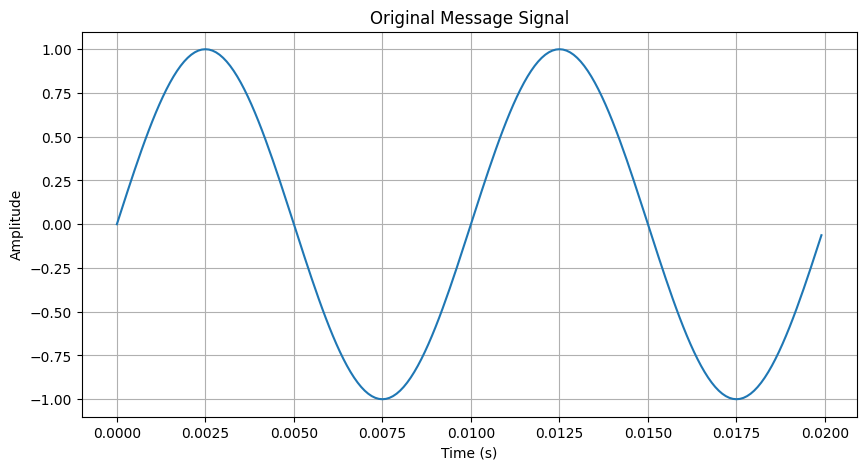

In [2]:
fs = 10000          # Sampling frequency
duration = 0.02     # Signal duration
fm = 100            # Message frequency

t = np.arange(0, duration, 1/fs)

x = np.sin(2 * np.pi * fm * t)

plt.figure()
plt.plot(t, x)
plt.title("Original Message Signal")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

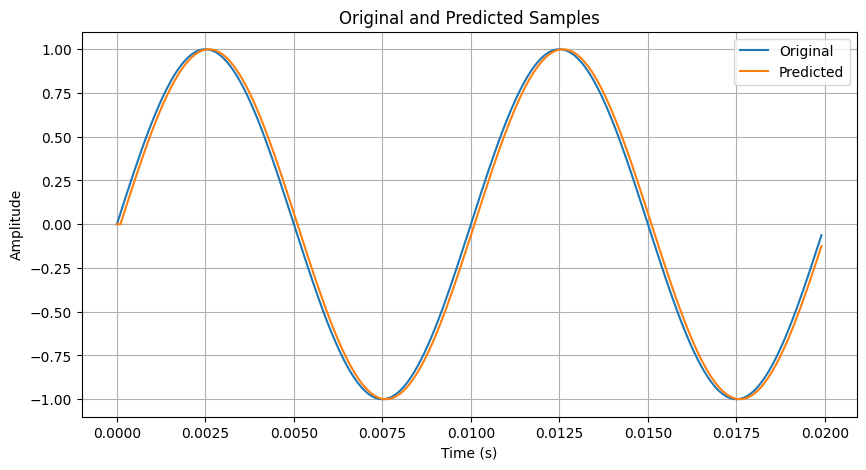

In [3]:
prediction = np.zeros_like(x)
prediction[0] = 0

for n in range(1, len(x)):
    prediction[n] = x[n-1]

prediction_error = x - prediction

plt.figure()
plt.plot(t, x, label="Original")
plt.plot(t, prediction, label="Predicted")
plt.title("Original and Predicted Samples")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.show()

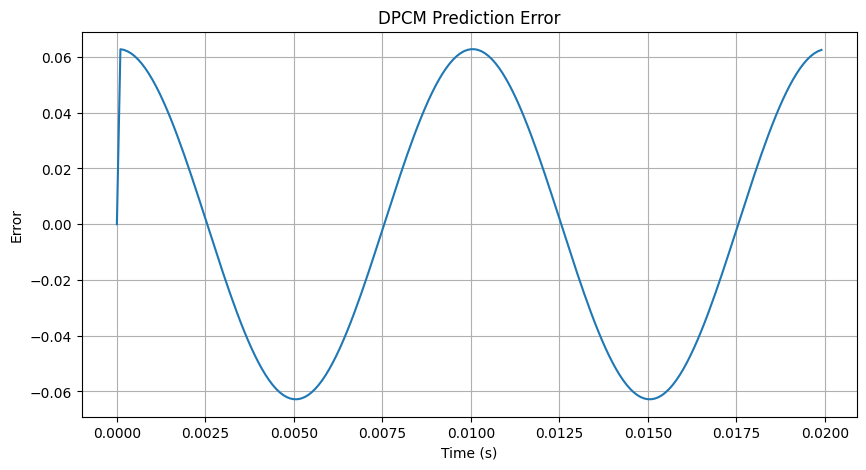

In [4]:
plt.figure()
plt.plot(t, prediction_error)
plt.title("DPCM Prediction Error")
plt.xlabel("Time (s)")
plt.ylabel("Error")
plt.show()

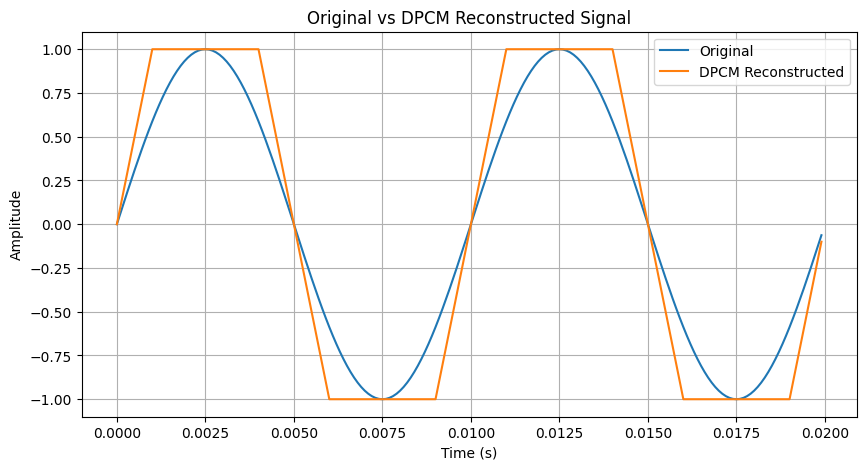

In [5]:
Delta_dpcm = 0.1

quantized_error = Delta_dpcm * np.round(
    prediction_error / Delta_dpcm
)

reconstructed = np.zeros_like(x)
reconstructed[0] = x[0]

for n in range(1, len(x)):
    reconstructed[n] = reconstructed[n-1] + quantized_error[n]

plt.figure()
plt.plot(t, x, label="Original")
plt.plot(t, reconstructed, label="DPCM Reconstructed")
plt.title("Original vs DPCM Reconstructed Signal")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.show()

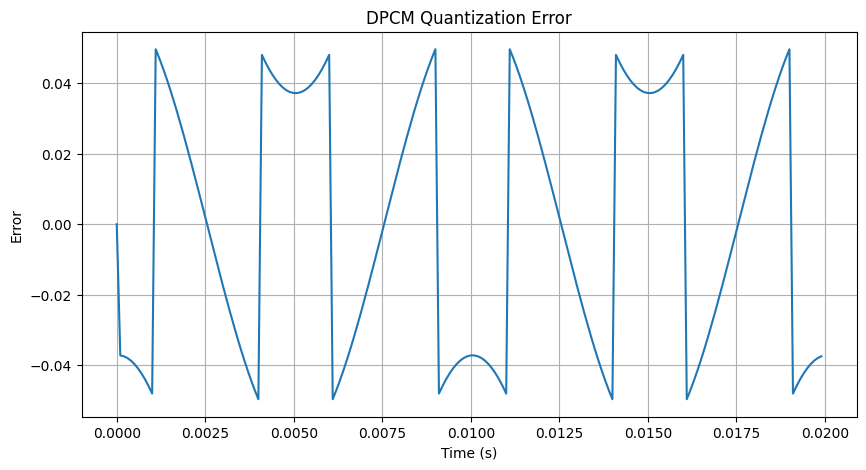

In [6]:
dpcm_quantization_error = prediction_error - quantized_error

plt.figure()
plt.plot(t, dpcm_quantization_error)
plt.title("DPCM Quantization Error")
plt.xlabel("Time (s)")
plt.ylabel("Error")
plt.show()

In [7]:
Delta_pcm = 0.1

pcm_quantized = Delta_pcm * np.round(x / Delta_pcm)
pcm_error = x - pcm_quantized

dpcm_mse = np.mean((x - reconstructed)**2)
pcm_mse = np.mean((x - pcm_quantized)**2)

print("PCM MSE  :", pcm_mse)
print("DPCM MSE :", dpcm_mse)

PCM MSE  : 0.0007484696513815104
DPCM MSE : 0.04250611600791006


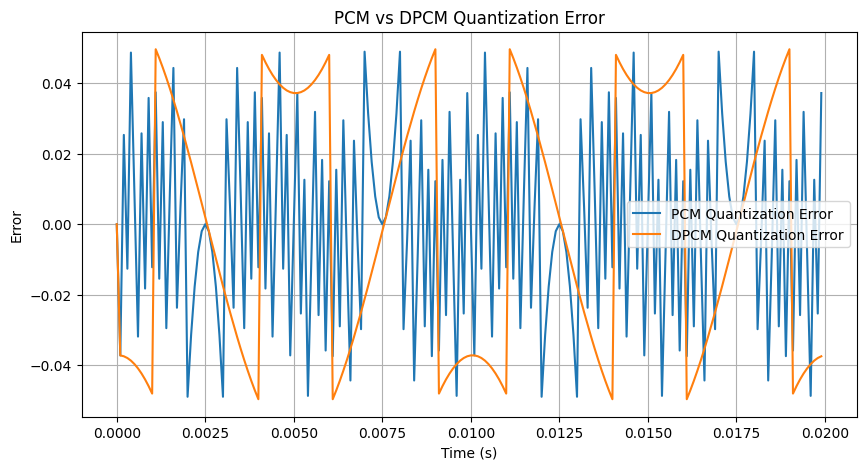

In [8]:
plt.figure()
plt.plot(t, pcm_error, label="PCM Quantization Error")
plt.plot(t, dpcm_quantization_error, label="DPCM Quantization Error")
plt.title("PCM vs DPCM Quantization Error")
plt.xlabel("Time (s)")
plt.ylabel("Error")
plt.legend()
plt.show()

In [9]:
def delta_modulation(x, Delta):
    staircase = np.zeros_like(x)
    bits = np.zeros(len(x), dtype=int)

    staircase[0] = 0

    for n in range(1, len(x)):
        if x[n] >= staircase[n-1]:
            bits[n] = 1
            staircase[n] = staircase[n-1] + Delta
        else:
            bits[n] = 0
            staircase[n] = staircase[n-1] - Delta

    return bits, staircase

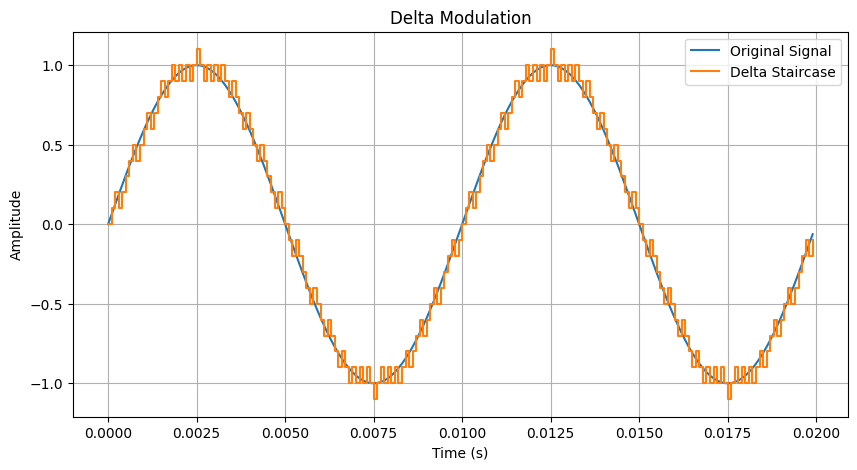

In [10]:
Delta = 0.1

bits, staircase = delta_modulation(x, Delta)

plt.figure()
plt.plot(t, x, label="Original Signal")
plt.step(t, staircase, where="post", label="Delta Staircase")
plt.title("Delta Modulation")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.show()

In [11]:
step_changes = np.diff(staircase)

valid_steps = np.all(
    np.isclose(np.abs(step_changes), Delta)
)

print("Delta =", Delta)
print("All staircase steps are exactly ±Delta:", valid_steps)

print("Unique step changes:")
print(np.unique(np.round(step_changes, 10)))

Delta = 0.1
All staircase steps are exactly ±Delta: True
Unique step changes:
[-0.1  0.1]


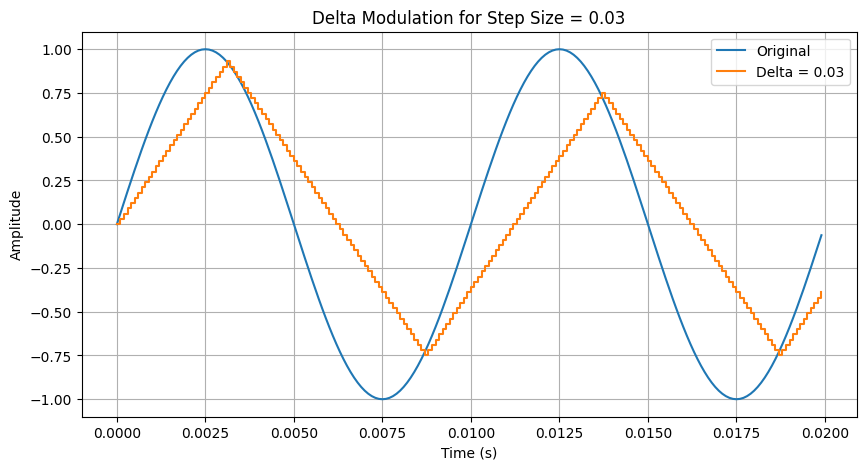

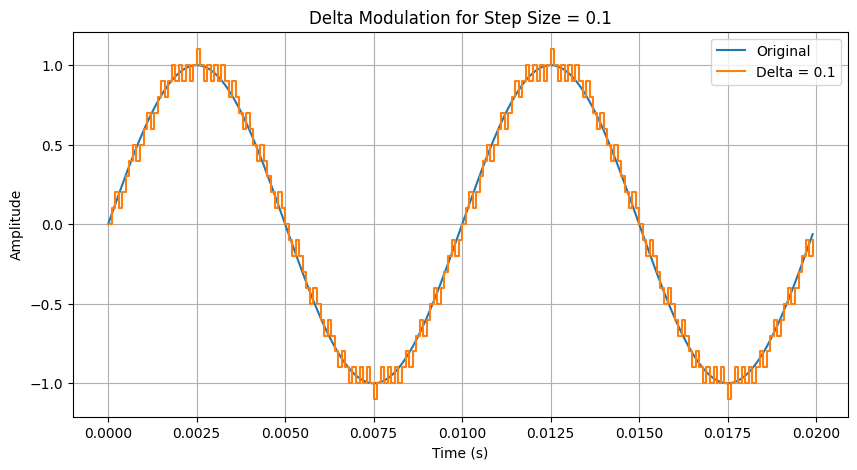

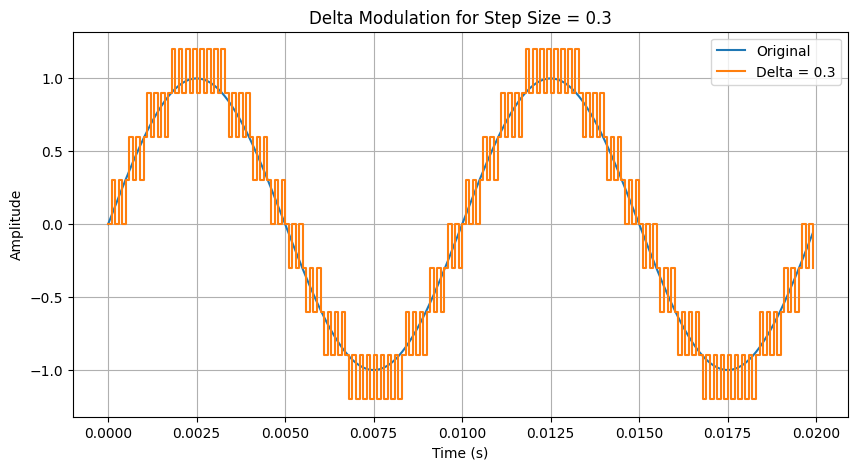

In [12]:
step_sizes = [0.03, 0.1, 0.3]

for Delta in step_sizes:
    bits, staircase = delta_modulation(x, Delta)

    plt.figure()
    plt.plot(t, x, label="Original")
    plt.step(t, staircase, where="post",
             label=f"Delta = {Delta}")
    plt.title(f"Delta Modulation for Step Size = {Delta}")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.show()

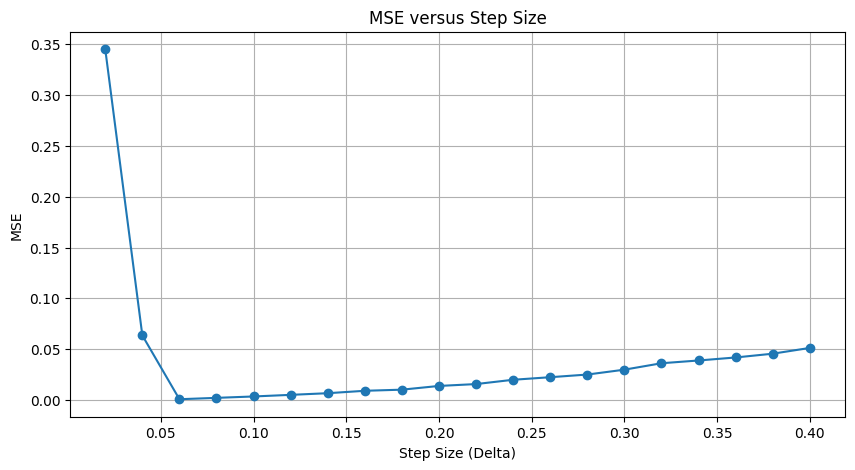

In [13]:
step_sizes = np.linspace(0.02, 0.4, 20)
mse_values = []

for Delta in step_sizes:
    bits, staircase = delta_modulation(x, Delta)

    mse = np.mean((x - staircase)**2)
    mse_values.append(mse)

plt.figure()
plt.plot(step_sizes, mse_values, marker='o')
plt.title("MSE versus Step Size")
plt.xlabel("Step Size (Delta)")
plt.ylabel("MSE")
plt.show()

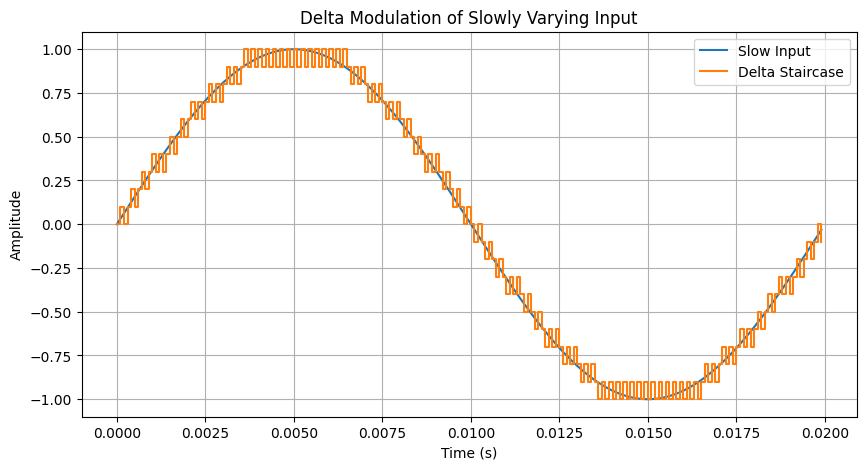

In [14]:
fm_slow = 50

x_slow = np.sin(2 * np.pi * fm_slow * t)

Delta = 0.1

bits_slow, staircase_slow = delta_modulation(x_slow, Delta)

plt.figure()
plt.plot(t, x_slow, label="Slow Input")
plt.step(t, staircase_slow, where="post",
         label="Delta Staircase")
plt.title("Delta Modulation of Slowly Varying Input")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.show()

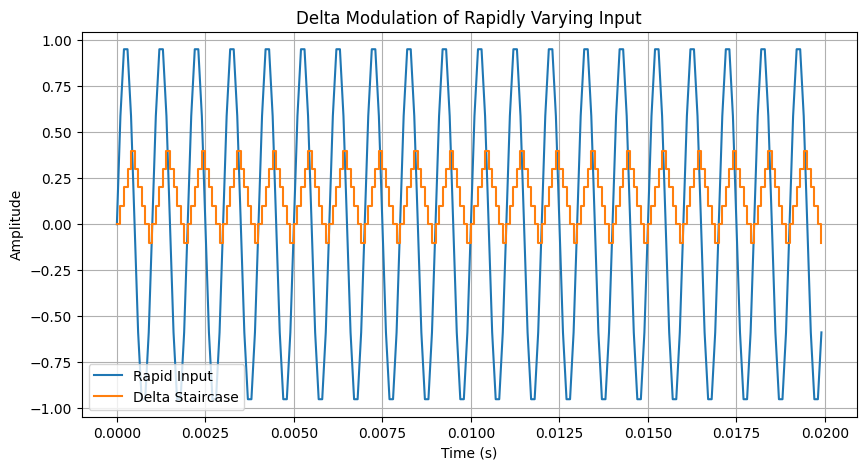

In [15]:
fm_fast = 1000

x_fast = np.sin(2 * np.pi * fm_fast * t)

Delta = 0.1

bits_fast, staircase_fast = delta_modulation(x_fast, Delta)

plt.figure()
plt.plot(t, x_fast, label="Rapid Input")
plt.step(t, staircase_fast, where="post",
         label="Delta Staircase")
plt.title("Delta Modulation of Rapidly Varying Input")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.show()

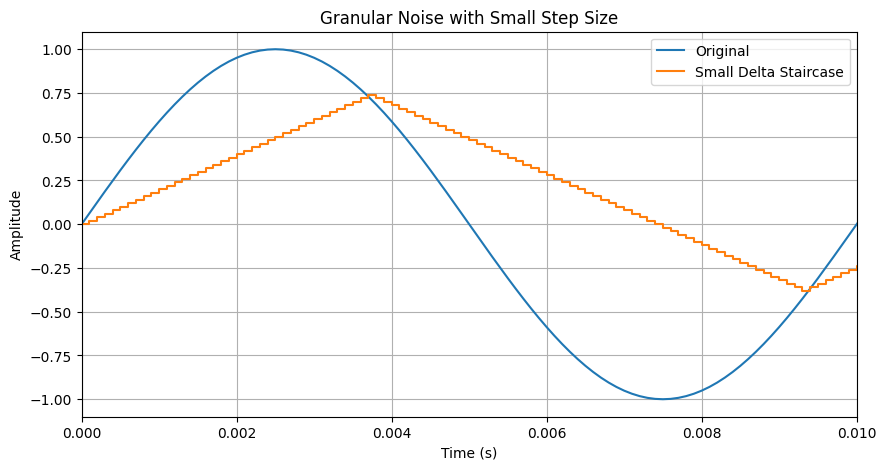

In [16]:
Delta_small = 0.02

bits_small, staircase_small = delta_modulation(x, Delta_small)

plt.figure()
plt.plot(t, x, label="Original")
plt.step(t, staircase_small, where="post",
         label="Small Delta Staircase")
plt.xlim(0, 0.01)
plt.title("Granular Noise with Small Step Size")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.show()

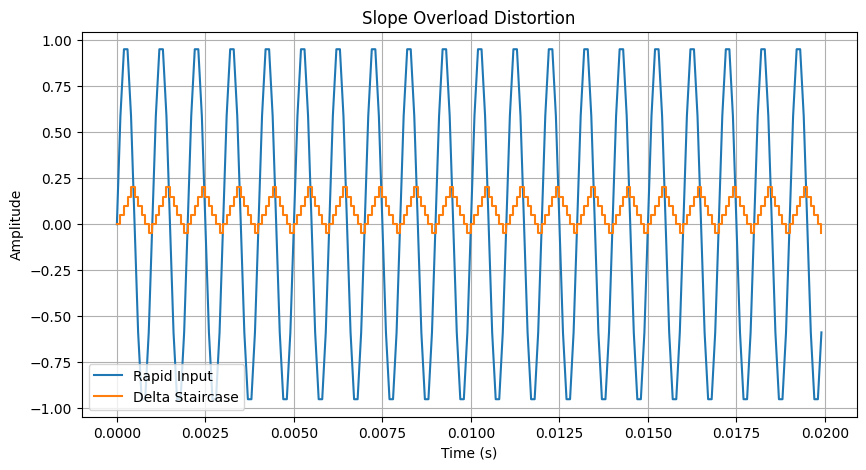

In [17]:
Delta_overload = 0.05

bits_overload, staircase_overload = delta_modulation(
    x_fast, Delta_overload
)

plt.figure()
plt.plot(t, x_fast, label="Rapid Input")
plt.step(t, staircase_overload, where="post",
         label="Delta Staircase")
plt.title("Slope Overload Distortion")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.show()

In [18]:
print("EXPERIMENT 5 RESULTS")
print("-" * 40)

for Delta in [0.03, 0.1, 0.3]:
    bits, staircase = delta_modulation(x, Delta)

    mse = np.mean((x - staircase)**2)
    changes = np.diff(staircase)

    valid = np.all(np.isclose(np.abs(changes), Delta))

    print(f"Delta = {Delta:.2f}")
    print(f"MSE = {mse:.6f}")
    print(f"Valid ±Delta steps = {valid}")
    print()

EXPERIMENT 5 RESULTS
----------------------------------------
Delta = 0.03
MSE = 0.196120
Valid ±Delta steps = True

Delta = 0.10
MSE = 0.003444
Valid ±Delta steps = True

Delta = 0.30
MSE = 0.029810
Valid ±Delta steps = True

